In [1]:
#Libraries for Machine Learning
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fall = pd.read_csv('Dataset/fall.csv', header = None)
non_fall = pd.read_csv('Dataset/nf.csv', header = None)
rest = pd.read_csv('Dataset/rest.csv', header = None)

fall[0] = 1
non_fall[0] = 2
rest[0] = 3

fin = pd.concat([fall,non_fall,rest])
fin = fin.sample(frac = 1)

In [3]:
x_inp = fin.iloc[:,1:].values
y_inp = fin.iloc[:,0].values

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_inp, y_inp, random_state = 0)

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [6]:
from matplotlib.colors import ListedColormap

def LDA_Plot(x_val, y_val, x_test, y_test, func, step = 0.01, title = "Title", dpi = 800):
    plt.figure(dpi = dpi)
    
    x_set, y_set = x_val, y_val
    #To get a meshgrid for plotting on contour
    x1, x2 = np.meshgrid( np.arange(start = x_set[:,0].min() - 1, stop = x_set[:,0].max() + 1, step = step),
                          np.arange(start = x_set[:,1].min() - 1, stop = x_set[:,1].max() + 1, step = step))
    #Plotting on the contour
    Z = func(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    plt.title("Decision Boundary - " + title)
    plt.savefig("Snips\\Decision Boundary - " + title)
    plt.show()
    
    plt.figure(dpi = dpi)
    
    plt.contourf(x1, x2, Z,
                 cmap = ListedColormap(('red', 'green', 'blue')), alpha = 0.75)
    #Limiting the plot to max & min units of x1 & x2
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    #Scatter plot of y_val
    for i, j in enumerate(np.unique(y_test)):
        plt.scatter(x_test[y_test==j, 0], x_test[y_test==j, 1], 
                    color = ListedColormap(("#8B0000", 'green', '#0000A0'))(i), label= j, s = 0.5) #Dark Red & Blue for clear visibility
    plt.title( "Scatter Plot on Decision Boundary - " + title)
    plt.legend()
    plt.savefig("Snips\\Scatter Plot on Decision Boundary - " + title)
    plt.show()

## Naive Bayes

In [7]:
from sklearn.naive_bayes import GaussianNB
classifier_NB = GaussianNB()
classifier_NB.fit(x_train, y_train)

y_pred = classifier_NB.predict(x_train)

In [8]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[8426 1358    0]
 [ 399 7578    0]
 [   0    0 8609]]
Accuracy (Train Data): 93.34 %


In [9]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9547875354107649
Sensitivity of Non-Fall for Train Data:  0.8480304386750224
Sensitivity of Rest for Train Data:  1.0
Sensitivity of Train Data:  93.42726580285957 %
Specificity of Fall for Train Data:  0.9225990310629809
Specificity of Non-Fall for Train Data:  0.9771136859011128
Specificity of Rest for Train Data:  0.9010753898992174
Specificity of Train Data 93.35960356211037 %


In [10]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_NB.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2844  429    0]
 [ 136 2551    0]
 [   0    0 2831]]
Accuracy (Test Data): 93.57 %


In [11]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9543624161073826
Sensitivity of Non-Fall for Test Data:  0.8560402684563758
Sensitivity of Rest for Test Data:  1.0
Sensitivity of Test Data:  93.68008948545862 %
Specificity of Fall for Test Data:  0.9261744966442953
Specificity of Non-Fall for Test Data:  0.9765961108242988
Specificity of Rest for Test Data:  0.9052013422818792
Specificity of Test Data 93.59906499168244 %


In [13]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_NB, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 93.42 %
Std of Accuracies:  0.00340799133220653


In [14]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Componenets: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Componenets:  0  Explained Variance Ratio: 0.7950  Variance Retained: 79.50 %
No. of Principal Componenets:  1  Explained Variance Ratio: 0.2050  Variance Retained: 100.00 %


In [15]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [16]:
# Analysing the SVM model fit with z_train
classifier_z = GaussianNB()
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [17]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8090  405    1]
 [1682 7572    0]
 [  12    0 8608]]
Accuracy (Z-Train Data): 92.04 %


In [18]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2734  536    3]
 [ 131 2556    0]
 [   0    0 2831]]
Accuracy (Z-Test Data): 92.38 %


In [19]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 91.74 %
Std of Accuracies:  0.004420606358246917


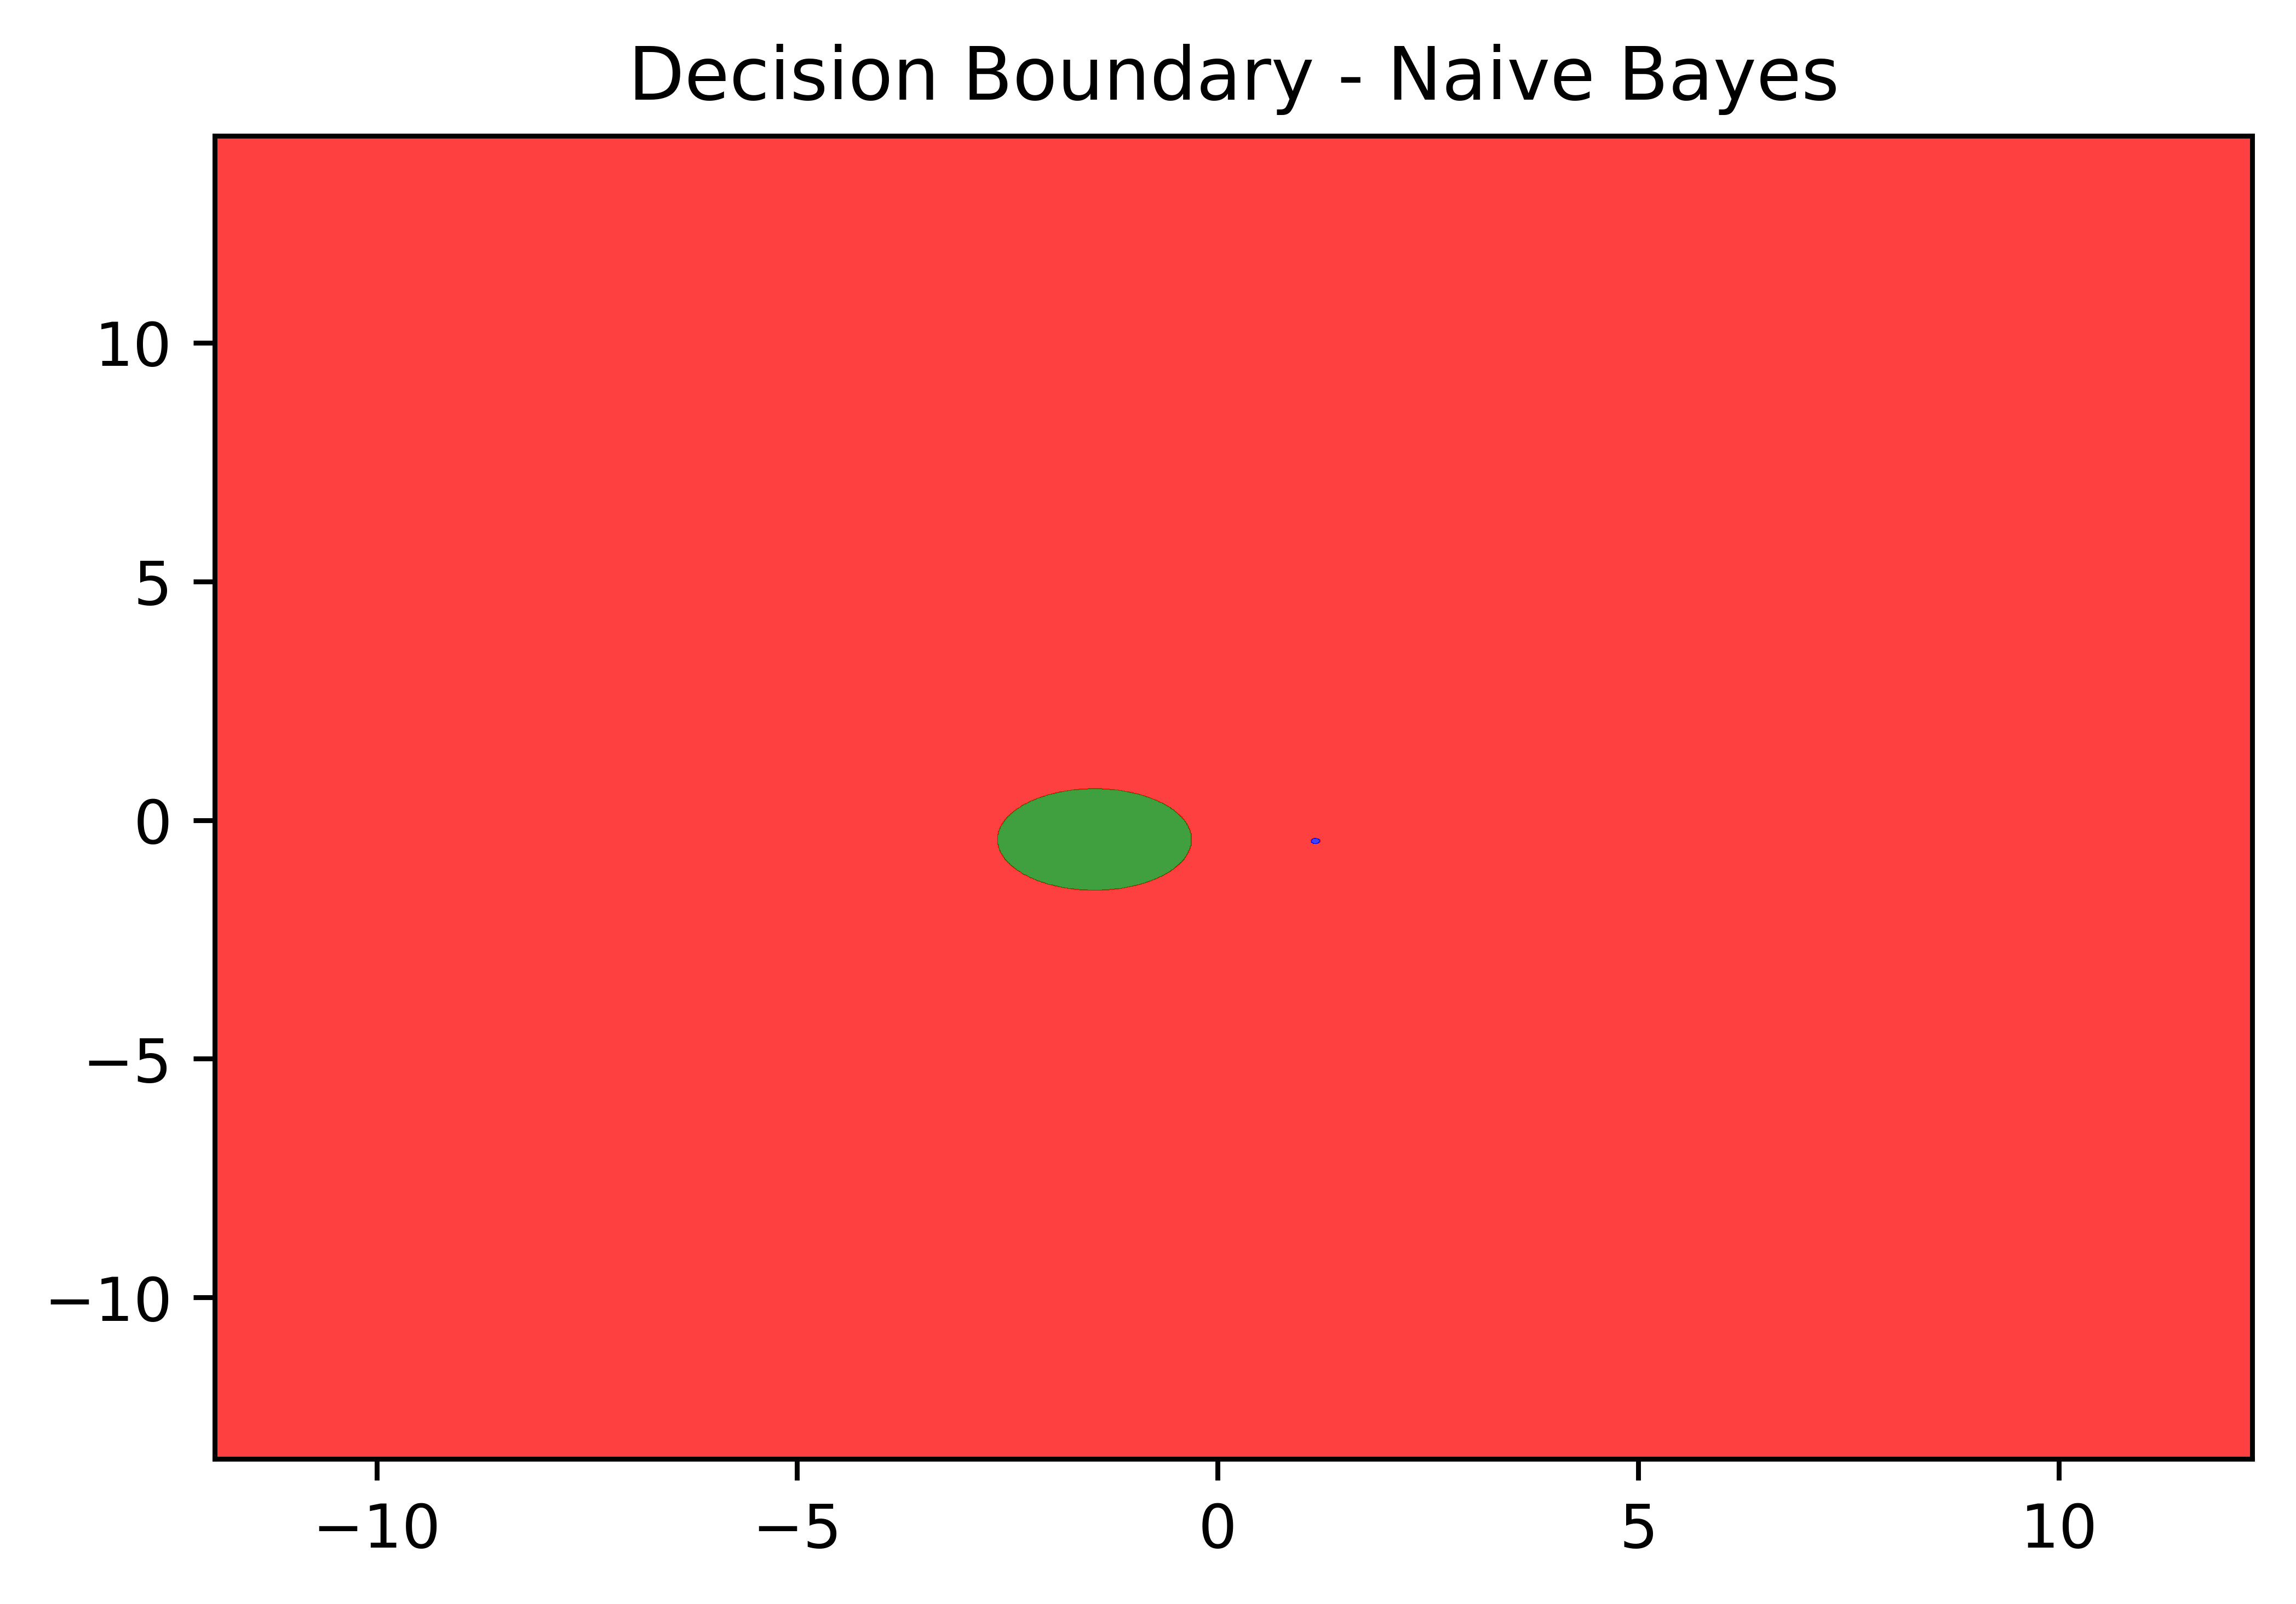

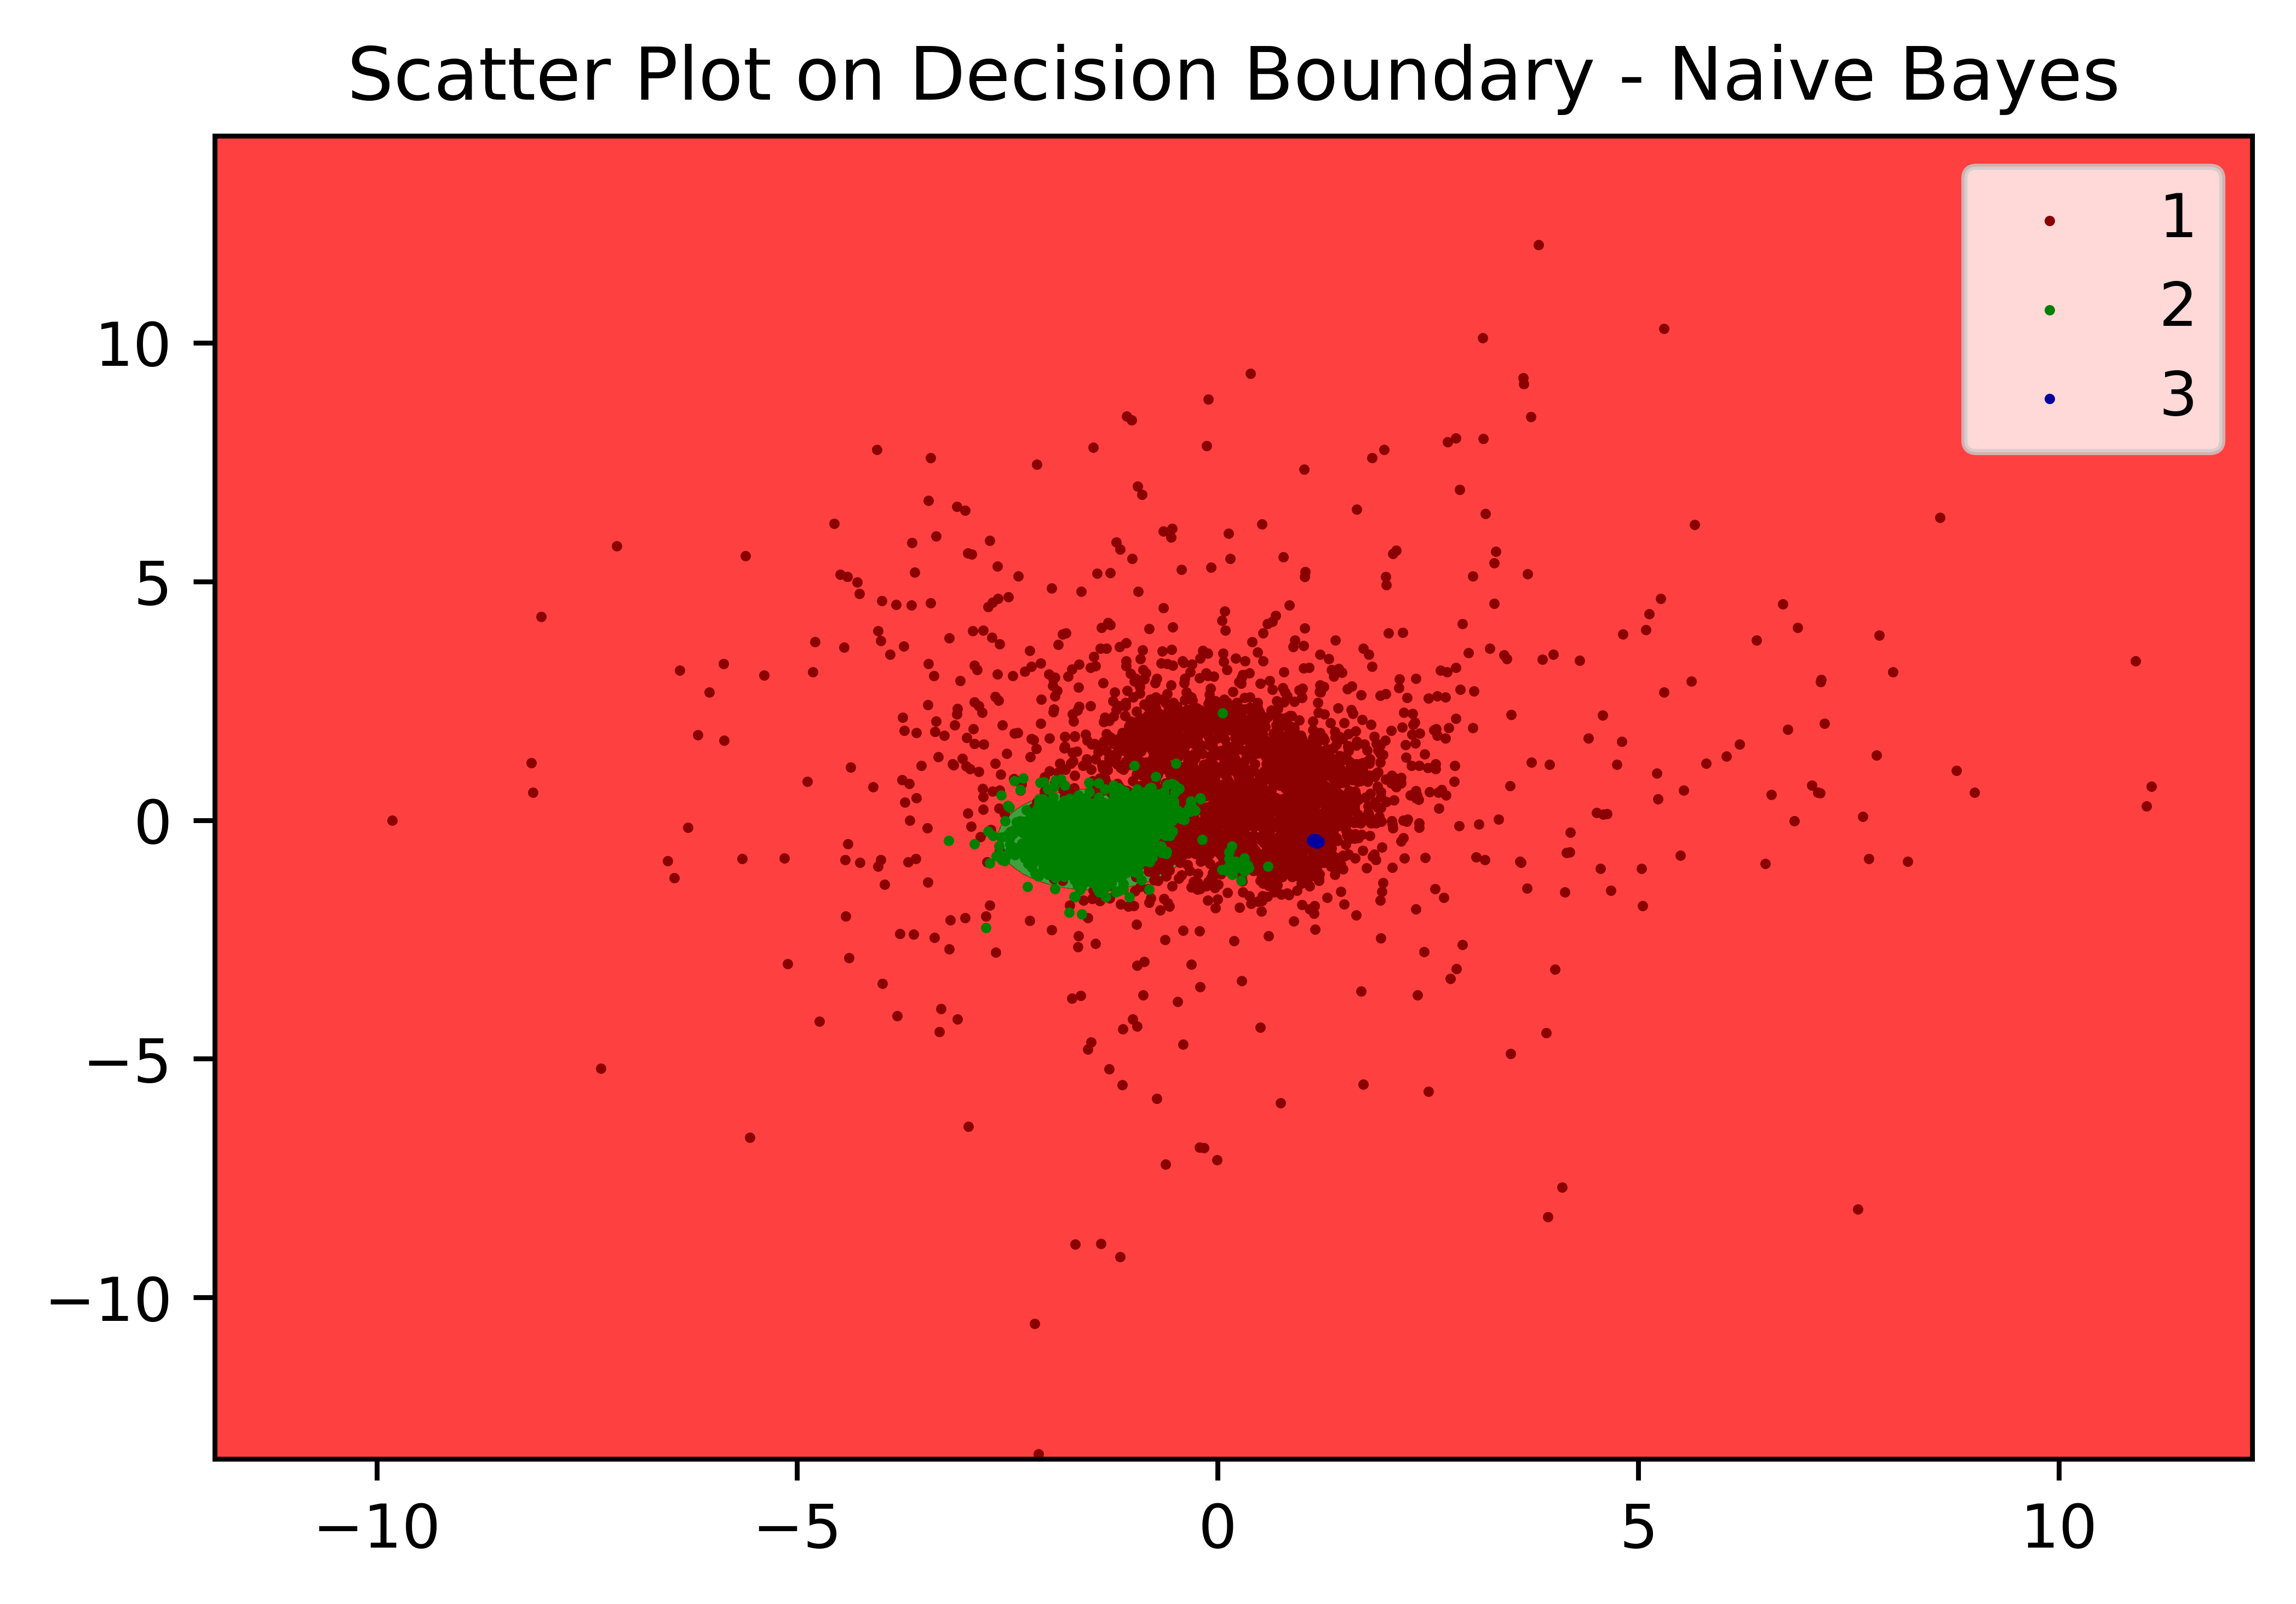

In [83]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "Naive Bayes", dpi = 800)

## Decision Tree Classification

In [20]:
from sklearn.tree import DecisionTreeClassifier
classifier_DT = DecisionTreeClassifier(criterion='entropy', min_samples_split = 100, min_samples_leaf = 80, random_state=0)
classifier_DT.fit(x_train, y_train)

y_pred = classifier_DT.predict(x_train)

In [21]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9381  397    6]
 [ 398 7579    0]
 [  36    0 8573]]
Accuracy (Train Data): 96.83 %


In [22]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9557819663779928
Sensitivity of Non-Fall for Train Data:  0.9502256770310933
Sensitivity of Rest for Train Data:  0.9993006177876209
Sensitivity of Train Data:  96.8436087065569 %
Specificity of Fall for Train Data:  0.9756569012382966
Specificity of Non-Fall for Train Data:  0.9760791562466021
Specificity of Rest for Train Data:  0.9532909898263167
Specificity of Train Data 96.83423491037385 %


In [23]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_DT.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3152  121    0]
 [ 162 2525    0]
 [  14    0 2817]]
Accuracy (Test Data): 96.62 %


In [24]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9471153846153846
Sensitivity of Non-Fall for Test Data:  0.95427059712774
Sensitivity of Rest for Test Data:  1.0
Sensitivity of Test Data:  96.71286605810415 %
Specificity of Fall for Test Data:  0.9778509976203551
Specificity of Non-Fall for Test Data:  0.9713588283157039
Specificity of Rest for Test Data:  0.9502845664546368
Specificity of Test Data 96.64981307968986 %


In [25]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_DT, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 96.87 %
Std of Accuracies:  0.0031683624976600357


In [26]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Componenets: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Componenets:  0  Explained Variance Ratio: 0.7950  Variance Retained: 79.50 %
No. of Principal Componenets:  1  Explained Variance Ratio: 0.2050  Variance Retained: 100.00 %


In [27]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [28]:
# Analysing the SVM model fit with z_train
classifier_z = DecisionTreeClassifier(criterion='entropy', min_samples_split = 100, min_samples_leaf = 80, random_state=0)
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [29]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8704  571   46]
 [1072 7406    0]
 [   8    0 8563]]
Accuracy (Z-Train Data): 93.56 %


In [31]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2912  358    3]
 [ 202 2485    0]
 [  18    0 2813]]
Accuracy (Z-Test Data): 93.39 %


In [32]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 93.05 %
Std of Accuracies:  0.003780318930105573


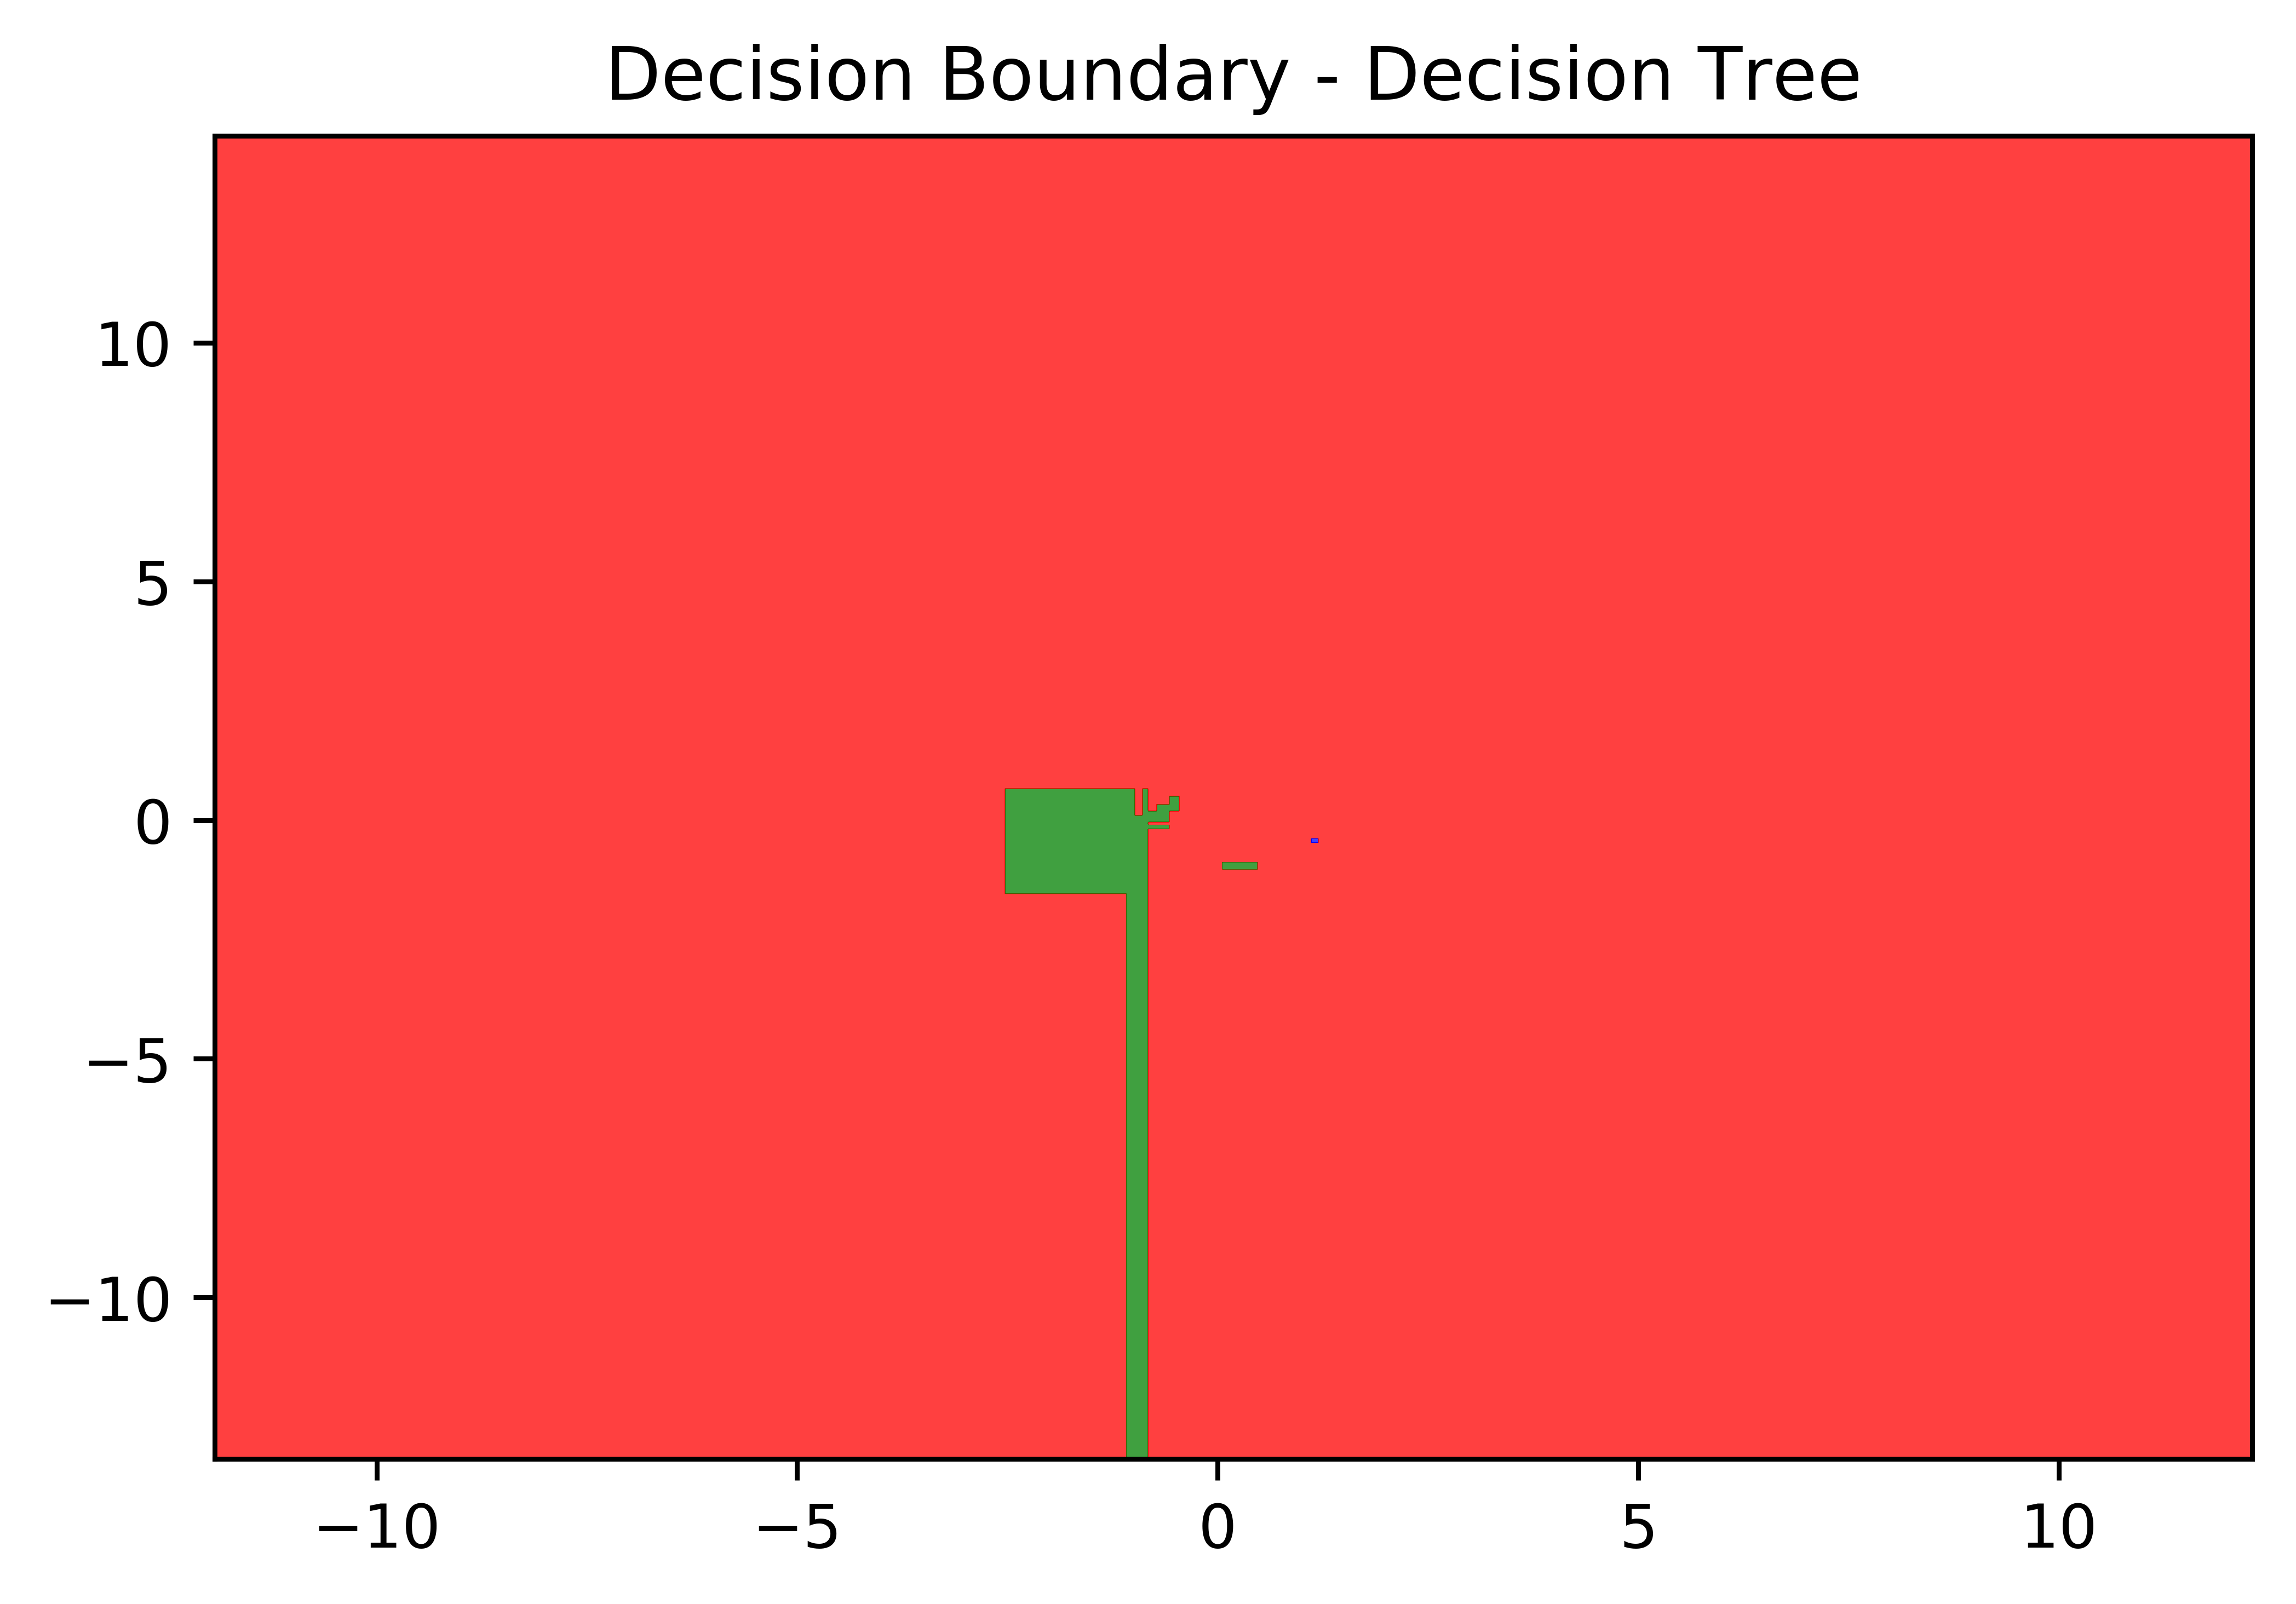

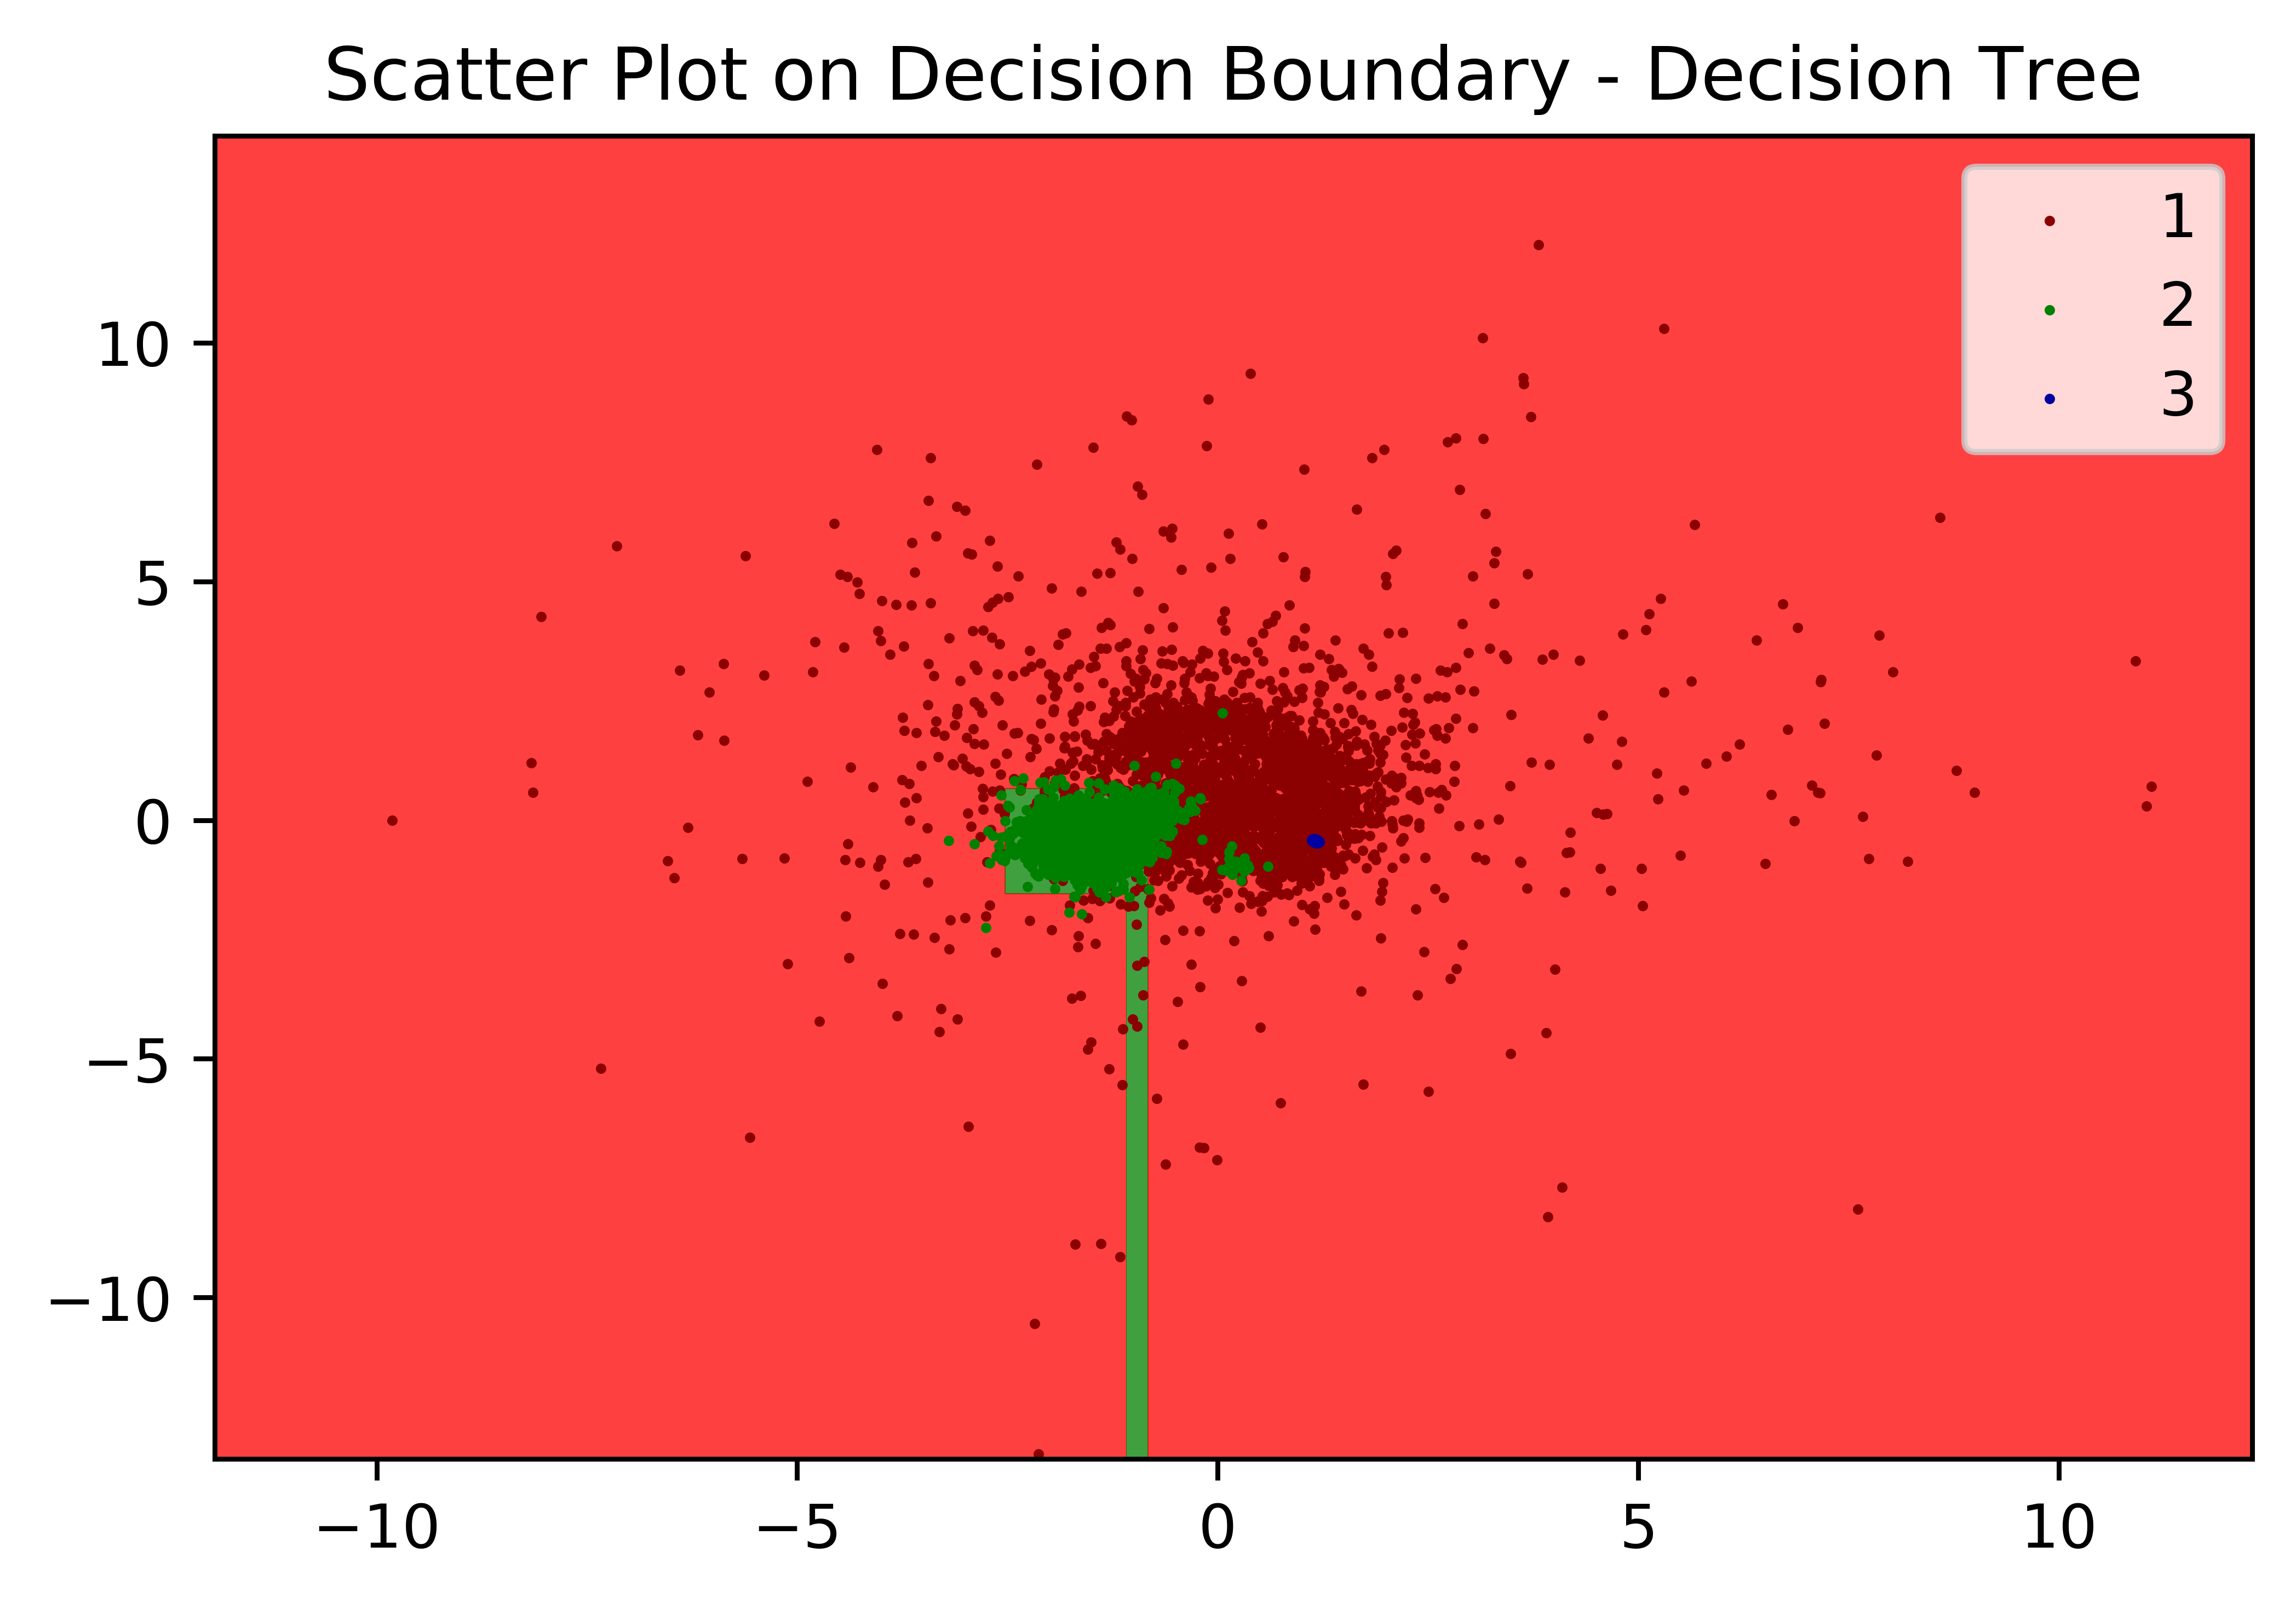

In [98]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "Decision Tree")

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
classifier_RF = RandomForestClassifier(n_estimators=120, min_samples_split = 80, min_samples_leaf = 80, criterion='entropy')
classifier_RF.fit(x_train, y_train)

y_pred = classifier_RF.predict(x_train)

In [34]:
#Confusion Matrix & Accuracy for evaluating the model for training data

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix (Train Data): \n", cm)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy (Train Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Train Data): 
 [[9485  297    2]
 [ 379 7598    0]
 [   1    0 8608]]
Accuracy (Train Data): 97.43 %


In [35]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Train Data: ", sen[0])
print("Sensitivity of Non-Fall for Train Data: ", sen[1])
print("Sensitivity of Rest for Train Data: ", sen[2])
print("Sensitivity of Train Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Train Data: ", spec[0] )
print("Specificity of Non-Fall for Train Data: ",  spec[1] )
print("Specificity of Rest for Train Data: ",  spec[2])
print("Specificity of Train Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Train Data:  0.9614799797263052
Sensitivity of Non-Fall for Train Data:  0.9623812539582014
Sensitivity of Rest for Train Data:  0.9997677119628339
Sensitivity of Train Data:  97.45429818824468 %
Specificity of Fall for Train Data:  0.9818842774916692
Specificity of Non-Fall for Train Data:  0.9793234100135318
Specificity of Rest for Train Data:  0.9618806306306307
Specificity of Train Data 97.4362772711944 %


In [36]:
# Confusion Matrix & Accuracy for evaluating the model for test data

y_pred = classifier_RF.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[3179   94    0]
 [ 153 2534    0]
 [   1    0 2830]]
Accuracy (Test Data): 97.18 %


In [20]:
sen = np.array([ cm[0][0]/sum(cm[:, 0]), cm[1][1]/sum(cm[:, 1]), cm[2][2]/sum(cm[:, 2]) ])
print("Sensitivity of Fall for Test Data: ", sen[0])
print("Sensitivity of Non-Fall for Test Data: ", sen[1])
print("Sensitivity of Rest for Test Data: ", sen[2])
print("Sensitivity of Test Data: ", sen.mean()*100, "%")

spec = np.array([ (cm[1][1] + cm[2][2])/(sum(cm[:, 1]) + sum(cm[:, 2])), 
                  (cm[0][0] + cm[2][2])/(sum(cm[:, 0]) + sum(cm[:, 2])),
                  (cm[0][0] + cm[1][1])/(sum(cm[:, 0]) + sum(cm[:, 1]))
                ])
print("Specificity of Fall for Test Data: ", spec[0] )
print("Specificity of Non-Fall for Test Data: ",  spec[1] )
print("Specificity of Rest for Test Data: ",  spec[2])
print("Specificity of Test Data: ", spec.mean()*100, "%")

Sensitivity of Fall for Test Data:  0.9596204320613769
Sensitivity of Non-Fall for Test Data:  0.9604398382204247
Sensitivity of Rest for Test Data:  0.9998830682881198
Sensitivity of Test Data:  97.33144461899738 %
Specificity of Fall for Test Data:  0.9809280855199223
Specificity of Non-Fall for Test Data:  0.9782750027088525
Specificity of Rest for Test Data:  0.9599842855539342
Specificity of Test Data 97.30624579275697 %


In [37]:
# 10_Fold CV accuracy

from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(estimator=classifier_RF, X=x_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 97.36 %
Std of Accuracies:  0.0029949884336236787


In [38]:
# Checking the optimal value of k such that, good amount of variance is retained
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=None)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)
explained_variance = lda.explained_variance_ratio_

# explained_variance gives us the non-cummulative value of the varaince retained
variance_retained = 0

# Finding the variance retained for decrease in principal components
for k, evr in enumerate(explained_variance):
    variance_retained += evr 
    print("No. of Principal Componenets: ", k, " Explained Variance Ratio: {:.4f}".format(evr), " Variance Retained: {:.2f} %".format(variance_retained*100))
    if (variance_retained >= 0.98):
        # Finding the smallest value of k such that 98% of the variance is reatined
        break

No. of Principal Componenets:  0  Explained Variance Ratio: 0.7950  Variance Retained: 79.50 %
No. of Principal Componenets:  1  Explained Variance Ratio: 0.2050  Variance Retained: 100.00 %


In [39]:
# Choosing k, such that 98% of the variance is reatined.
# But, here even for k = 1, 100% variance is retained. So, for better data visualisation k=2 is chosen
lda = LDA(n_components=2)
# Transforming z_train & z_test using the new reduced dimension vector (U_reduce)
z_train = lda.fit_transform(x_train, y_train)
z_test = lda.transform(x_test)

In [40]:
# Analysing the SVM model fit with z_train
classifier_z = RandomForestClassifier(n_estimators=120, min_samples_split = 80, min_samples_leaf = 80, criterion='entropy')
classifier_z.fit(z_train, y_train)
y_z_pred = classifier_z.predict(z_train)

In [41]:
cm = confusion_matrix(y_z_pred, y_train)
print("Confustion Matrix (Z-Test Data): \n", cm)
accuracy = accuracy_score(y_train, y_z_pred)
print("Accuracy (Z-Train Data): {:.2f} %".format(accuracy*100))

Confustion Matrix (Z-Test Data): 
 [[8644  474    1]
 [1131 7503    0]
 [   9    0 8608]]
Accuracy (Z-Train Data): 93.88 %


In [43]:
y_z_pred = classifier_z.predict(z_test)

cm = confusion_matrix(y_test, y_z_pred)
print("Confusion Matrix (Test Data): \n", cm)
accuracy = accuracy_score(y_test, y_z_pred)
print("Accuracy (Z-Test Data): {:.2f} %".format(accuracy*100))

Confusion Matrix (Test Data): 
 [[2894  377    2]
 [ 151 2536    0]
 [   2    0 2829]]
Accuracy (Z-Test Data): 93.95 %


In [44]:
# 10_Fold CV accuracy

z_inp = lda.transform(x_inp)

accuracies = cross_val_score(estimator=classifier_z, X=z_inp, y=y_inp, cv=10, n_jobs=-1)
print("Mean of Accuracies: {:.2f} %".format(accuracies[1:].mean()*100))
print("Std of Accuracies: ", accuracies[1:].std())

Mean of Accuracies: 93.33 %
Std of Accuracies:  0.0042524955426632175


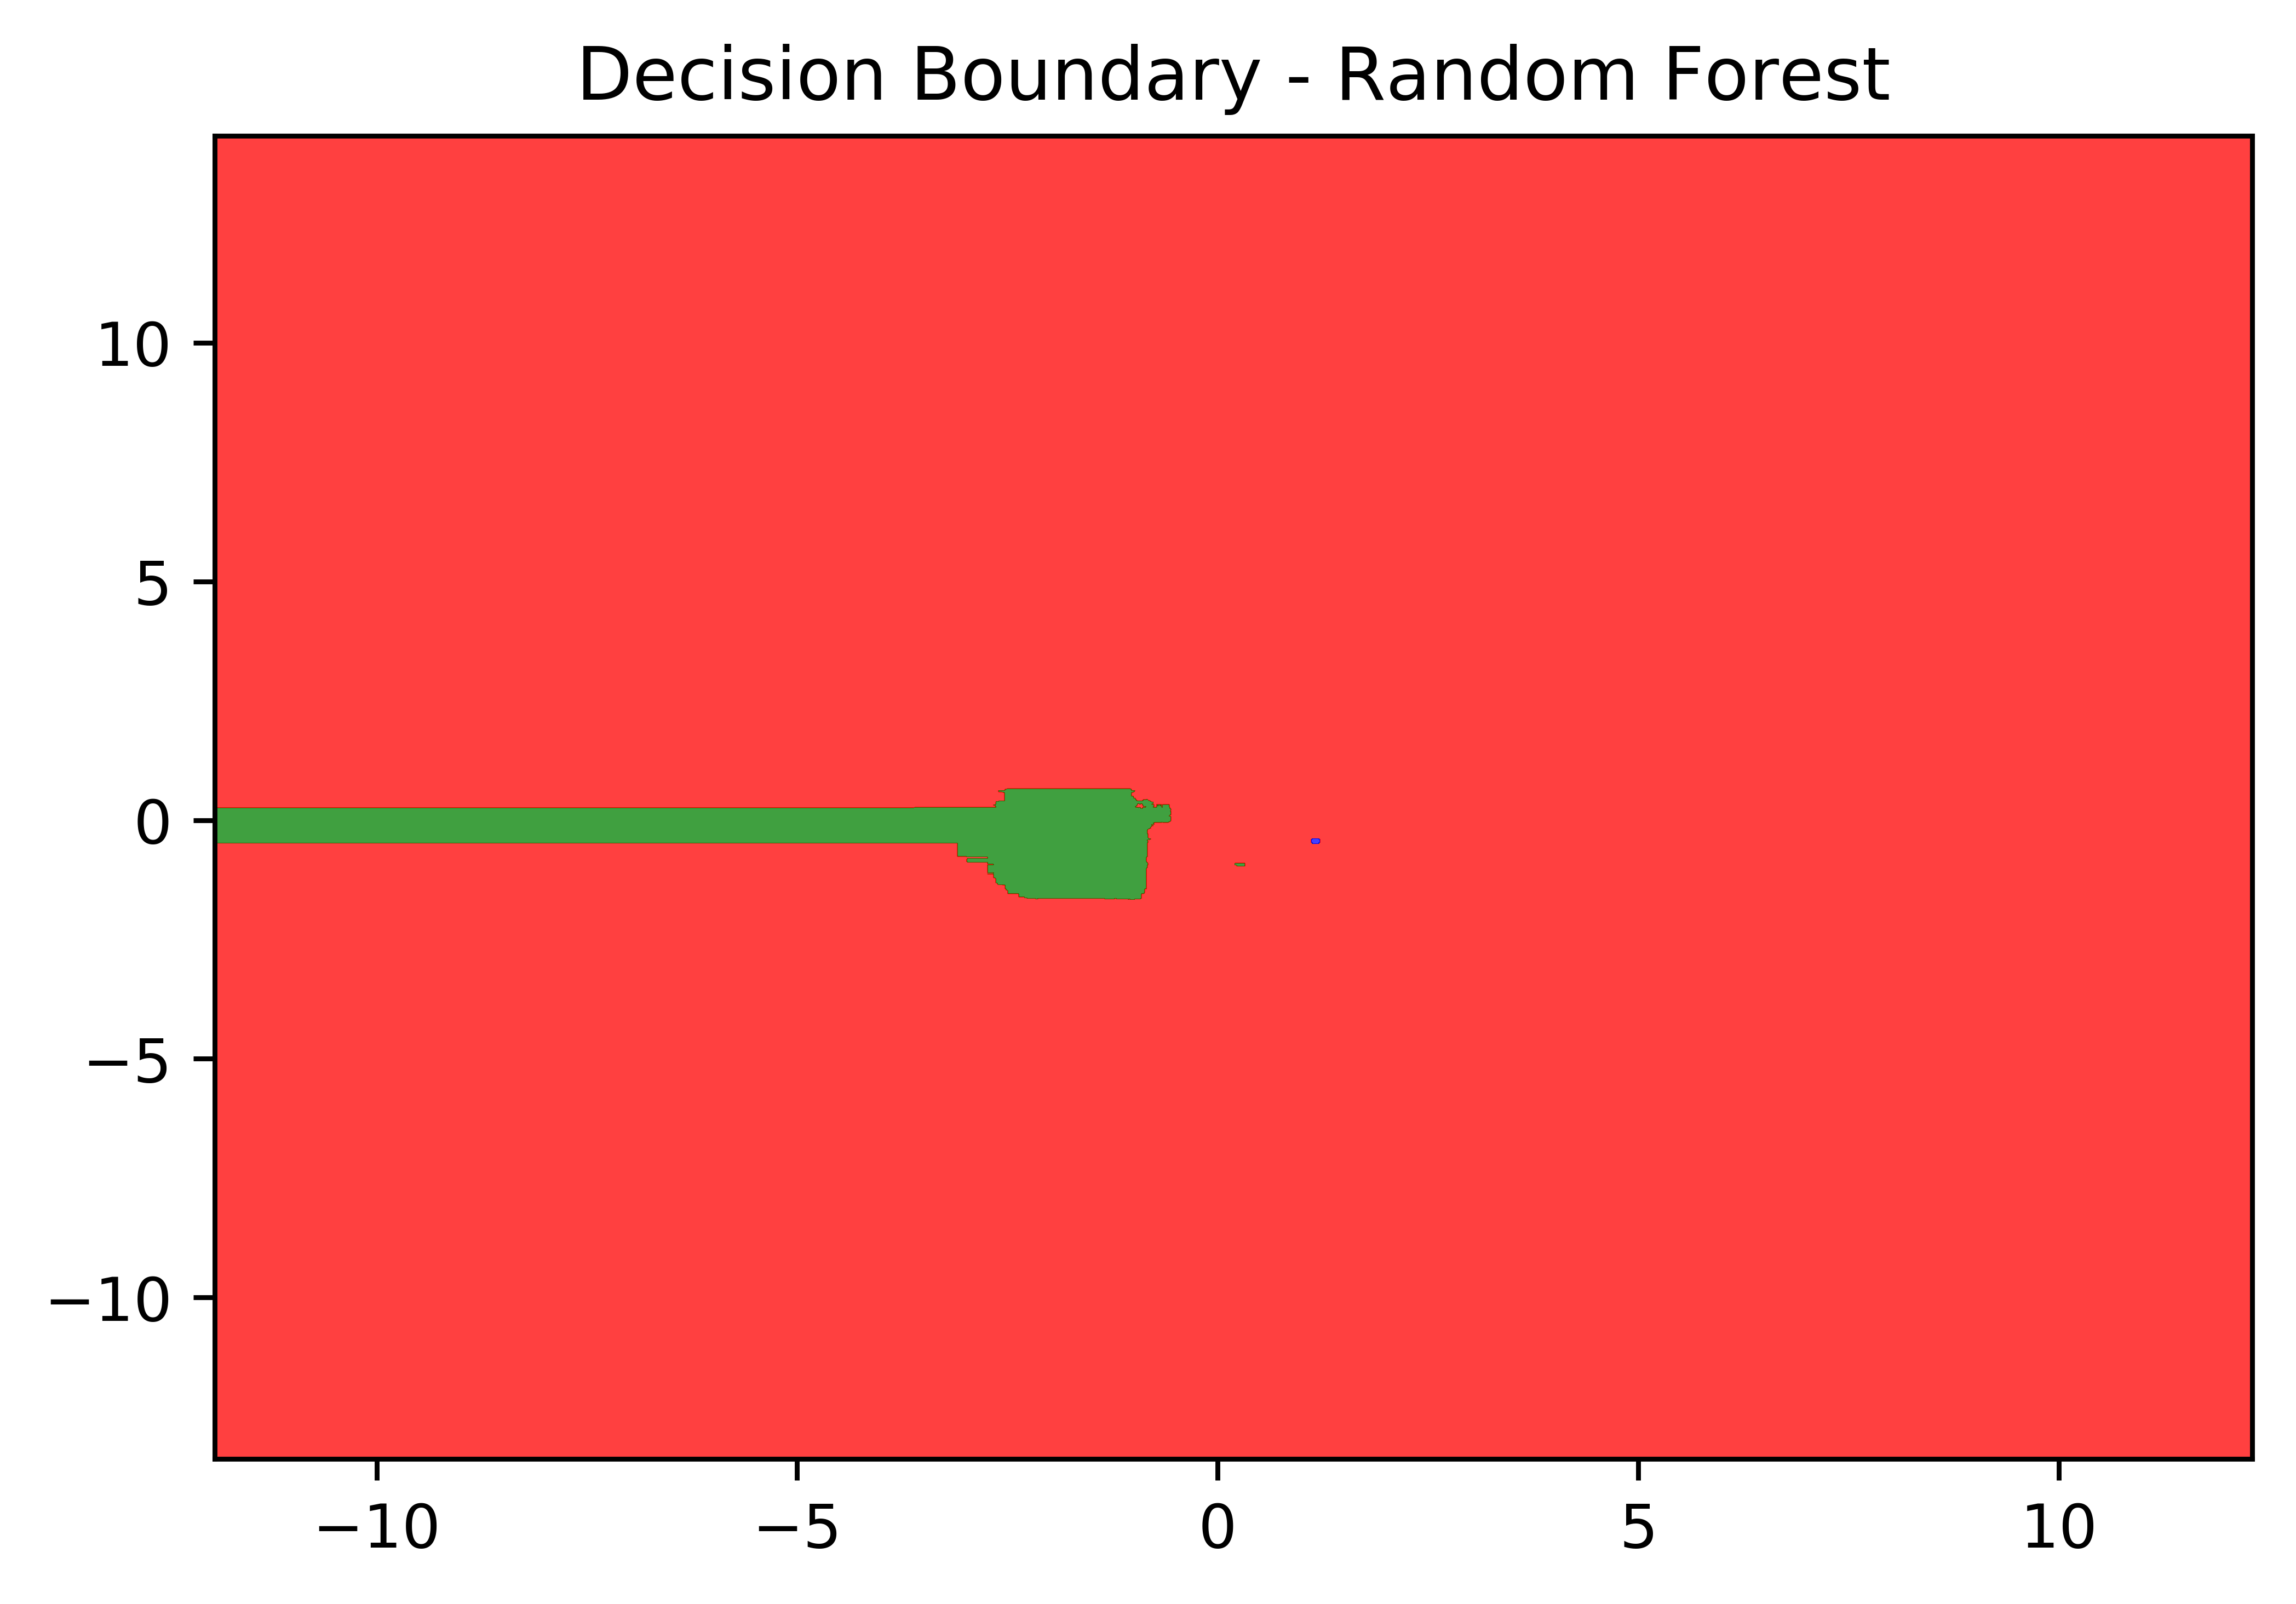

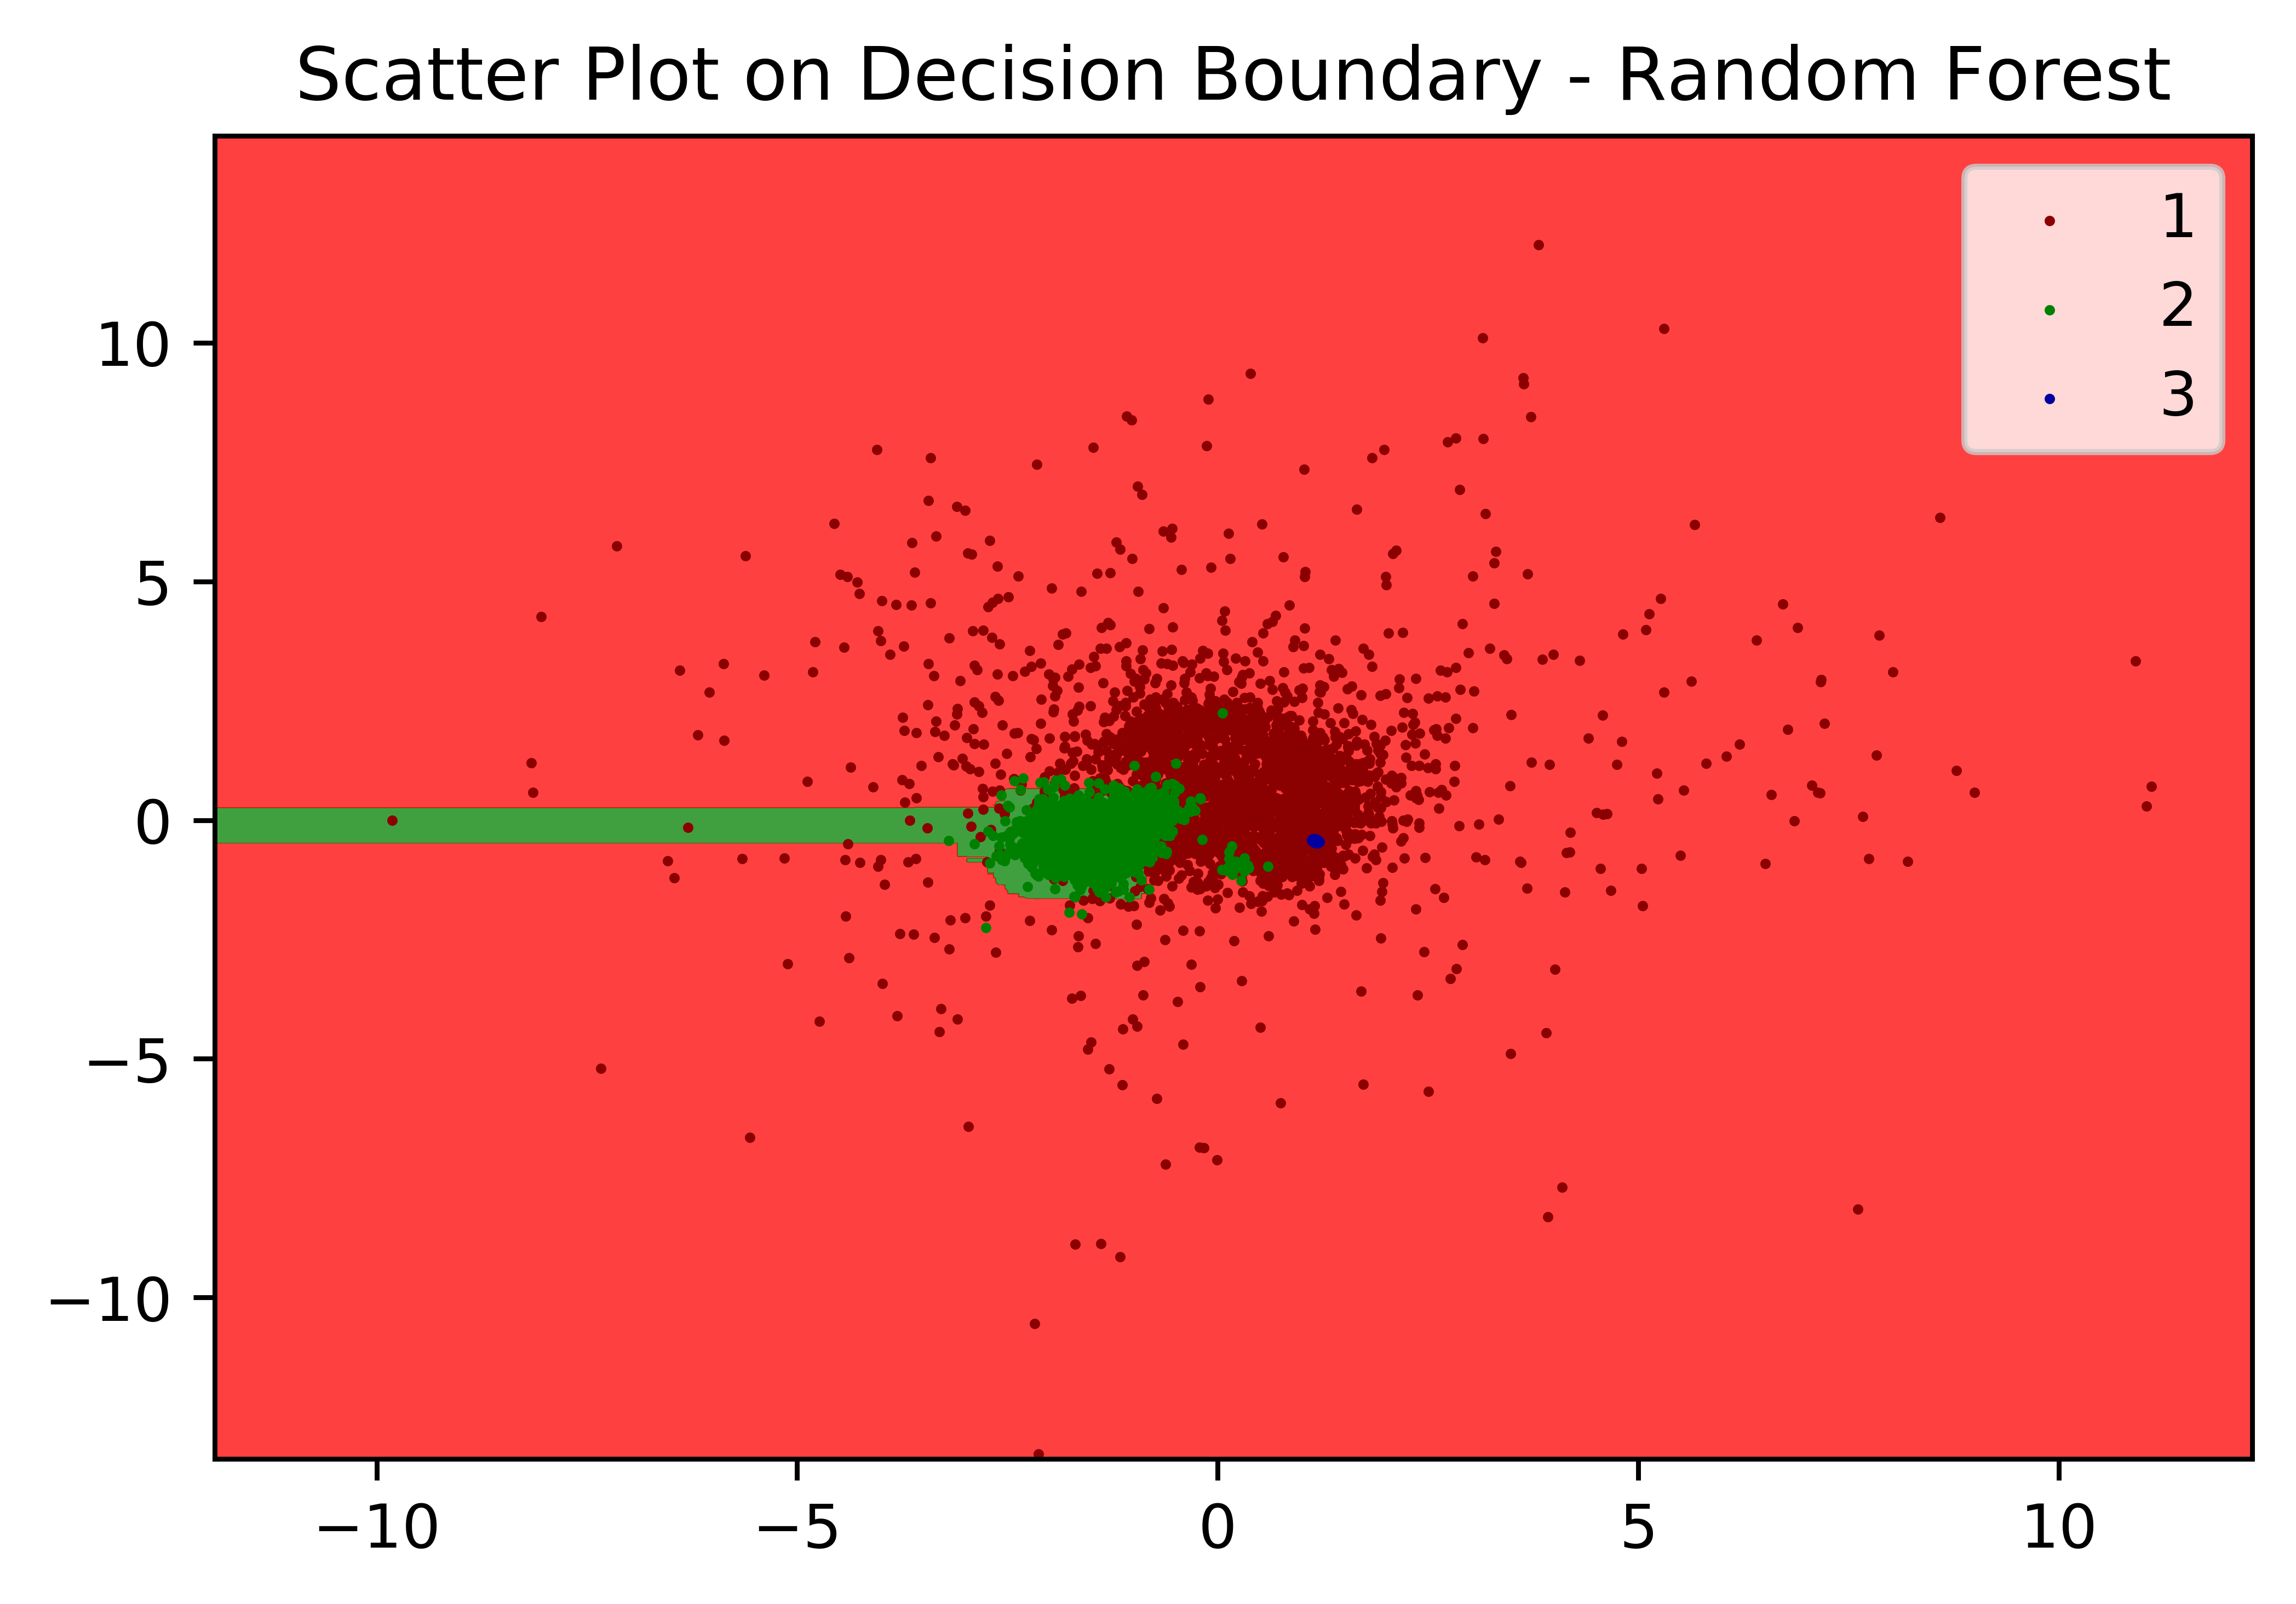

In [114]:
LDA_Plot(z_train, y_train, z_test, y_test, func = classifier_z.predict ,title = "Random Forest")